# Deep Hedging Frictions 

Copyright (c) jfyo2 2026. This 

## Introduction 

In 2019, Buehler et al. published the paper "Deep Hedging" [[1]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4151041), proposing a new framework for hedging under market frictions (transaction costs, risk limits, etc.). Buehler's [website](http://www.deephedging.com) describes the motivation for this method as follows: 

>The ambition of learning to trade is moving away from classic model-driven pricing and hedging methodologies and focus instead on real life performance of our now data-driven models ... Essentially, we propose to solve the original hedging problem, using data and AI ... For products which have no observable market prices, or for portfolios with path dependence, we have developed Deep Hedging.

In short, the idea is to replace classical models (Black-Scholes/Greeks/risk-neutral measures) with a neural network trained on real data that aims to output a hedging strategy which minimises a risk-adjusted objective loss function.

The purpose of this notebook is as follows: we aim to implement the deep hedging method in Python and compare its performance to classical delta hedging with respect to two synthetic models of asset prices: geometric Brownian motion (GBM) and the Heston model. We aim to answer the question: where does the deep hedging 'learned hedge' earn its keep compared to classical delta hedging, if anywhere? We will also provide some basic commentary on results. 

In [64]:
# Add project folder to PATH so this notebook can read things in src
import sys, os
sys.path.append(os.path.abspath('..'))

# Import main libraries 
import math 
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pandas as pd 
import torch 
import torch.nn as nn 

# Import project libraries 
from src import gbm, pricer, heston, deltahedge, deephedging 
from src.config import * 


importlib.reload(gbm) # Tell gbm to reload whenever updated 
importlib.reload(pricer)
importlib.reload(heston)
importlib.reload(deltahedge) 
importlib.reload(deephedging)

print("Import complete.")


Import complete.


## 1. Option Pricing under Geometric Brownian Motion

First we simulate a number of possible price trajectories of an underlying asset under geometric Brownian motion (GBM), i.e. the price trajectories move according to the SDE $dS = \mu S_t dt + \sigma S_t dW_t$, where $W_t$ is a standard Brownian motion. In particular we implement this using Ito's analytic solution to this SDE, which is $S_t = S_0 \exp\left((\mu - \sigma^2/2) t + \sigma W_t\right)$.

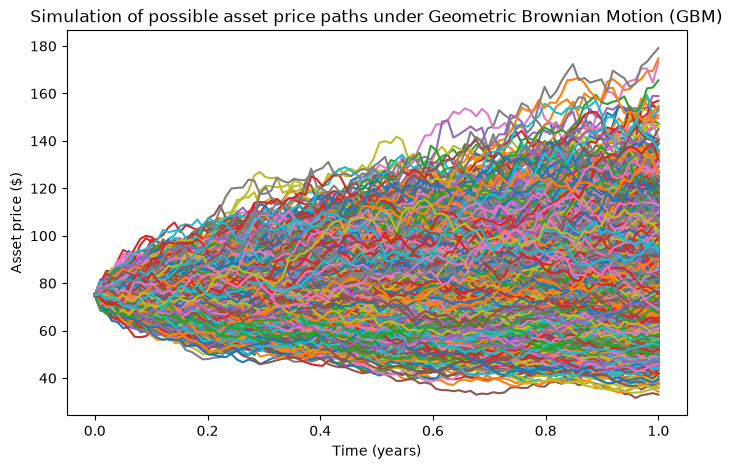

In [14]:
# Generate separate child seeds for each asset path so they are not the same 
ss = np.random.SeedSequence(42)
child_seeds = ss.spawn(NO_PATHS)
generators = [np.random.default_rng(s) for s in child_seeds]

paths_gbm = []

# Plot asset paths and add to 'paths' list for later analysis
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for rng in generators:
    (ts, GBM) = gbm.geometricBrownianMotion(rng, S_0, R, SIGMA, T, STEPS + 1)
    paths_gbm.append(GBM)
    ax.plot(ts, GBM)
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Asset price ($)")
    ax.set_title("Simulation of possible asset price paths under Geometric Brownian Motion (GBM)")

# Convert 'paths' list to a numpy array for consistency
paths_array_gbm = np.array(paths_gbm)


Next we price a corresponding European call option for the asset simulated above using Monte Carlo. Recall that the price of a European call option is given by 

$e^{-rT} \mathbb{E} (\max (S_T - K, 0))$

where $S_T$ is the price of the underlying asset at time $T$, $K$ is the strike price of the option, and $r$ is the risk-free rate. With our Monte-Carlo model, we can estimate this by just taking the empirical average:

$e^{−rT} \frac{1}{N} \sum_{i=1}^N \max(S_T(i)​−K,0)$

for $N$ paths. 

In [15]:
time = 1 # Time to calculate the option price at 
OP_mc = pricer.option_price_mc(ts, paths_array_gbm, time, K, R)

print(f'The price of a European call option at time %.2f for the simulated asset is estimated \nas %.4f by Monte-Carlo.'%(T,OP_mc))


The price of a European call option at time 1.00 for the simulated asset is estimated 
as 9.5723 by Monte-Carlo.


For completeness, let's verify this against Black-Scholes-Merton (BSM). The BSM model says that the price of a European call option is given by 

$S_0 \Phi(d_1) - Ke^{-rT} \Phi (d_2)$

where

$d_1 = \frac{\log (S_0 /K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma \sqrt{T}}, \qquad d_2 = d_1 - \sigma \sqrt{T}$

and $\Phi$ is the standard normal CDF. 

In [16]:
OP_bsm = pricer.option_price_bsm(S_0, K, T, R, SIGMA)

print(f'The Black-Scholes-Merton theoretical price of a European call option at time %.2f \nfor the simulated GBM asset is %.4f'%(T,OP_bsm))

direction = 'higher' if OP_mc > OP_bsm else 'lower'
distance = np.abs(OP_mc - OP_bsm)
print(f'The Monte-Carlo estimate is %.4f %s than the theoretical BSM price.'%(distance, direction))

The Black-Scholes-Merton theoretical price of a European call option at time 1.00 
for the simulated GBM asset is 9.2520
The Monte-Carlo estimate is 0.3203 higher than the theoretical BSM price.


## 2. The Heston model 

The classic GBM model used in Black-Scholes-Merton makes the unrealistic assumption that volatility remains constant throughout an option's lifespan. The Heston model improves upon this by assuming instead that the volatility varies according to an SDE.


The Heston model assumes that the asset price $S_t$ varies according to 

$dS_t = \mu S_t dt + \sqrt{\nu_t} S_t dW_t^S$

where the volatility $\sqrt{\nu_t}$ is given by the process 

$d\nu_t = \kappa (\theta - \nu_t) dt + \xi \sqrt{\nu_t} dW_t^\nu$

for Brownian motions $W_t^S$ and $W_t^\nu$ with correlation $\rho$. Note that 

- $\theta$ is the long-run average variance 
- $\kappa$ is the rate at which $\nu_t$ reverts to $\theta$
- $\xi$ is the volatility of the volatility.


Our model simulates this process using Euler-Maruyama discretization, since unlike for GBM there isn't an analytic solution. 

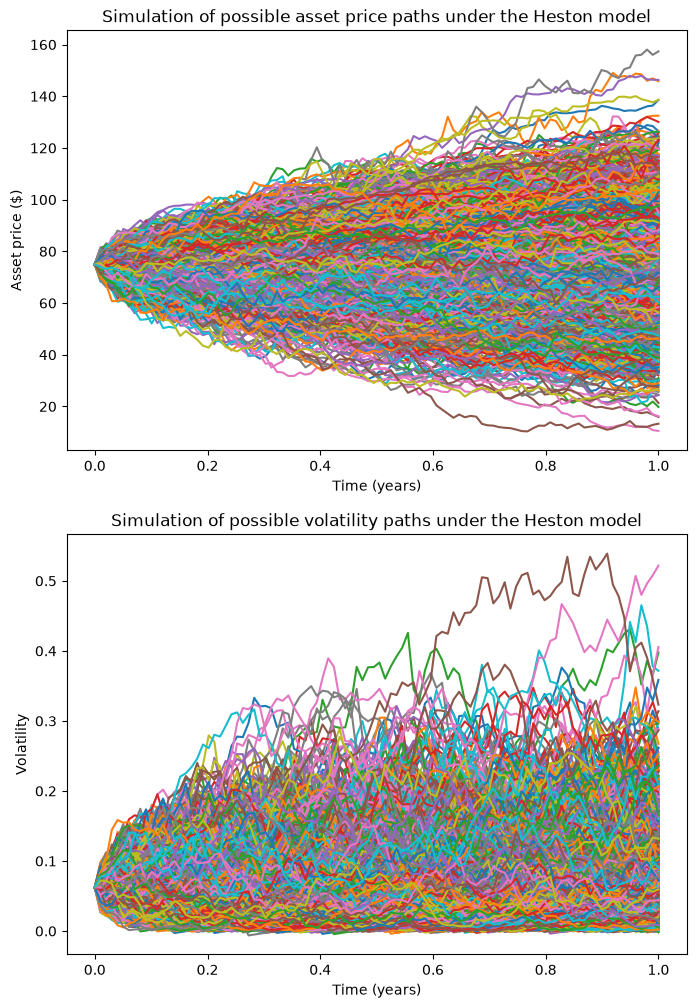

In [17]:
# Arrays to store price and volatility paths 
paths_heston = []
vols = []

# Plot asset paths and add to 'paths'/'vol' lists for later analysis
fig, ax = plt.subplots(2, 1, figsize=(8,12))
for rng in generators:
    (t, S, nu) = heston.hestonSim(rng, S_0, NU_0, R, KAPPA, THETA, XI, RHO, T, STEPS + 1)
    paths_heston.append(S)
    vols.append(nu)

    ax[0].plot(t, S)
    ax[0].set_xlabel("Time (years)")
    ax[0].set_ylabel("Asset price ($)")
    ax[0].set_title("Simulation of possible asset price paths under the Heston model")

    ax[1].plot(t, nu)
    ax[1].set_xlabel("Time (years)")
    ax[1].set_ylabel("Volatility")
    ax[1].set_title("Simulation of possible volatility paths under the Heston model")

# Convert 'paths' list to a numpy array for consistency
paths_array_heston = np.array(paths_heston)
vols_array = np.array(vols)

Let's use our Monte-Carlo pricer again to see what the average price of an option in this Heston model will be:

In [18]:
OP_heston_mc = pricer.option_price_mc(ts, paths_array_heston, T, K, R)

print(f'The price of a European call option at time %.2f for the simulated Heston asset is estimated \nas %.4f by Monte-Carlo.'%(T,OP_heston_mc))
direction = 'higher' if OP_heston_mc > OP_bsm else 'lower'
distance = np.abs(OP_heston_mc - OP_bsm)
print(f'The Monte-Carlo estimate is %.4f %s than the theoretical BSM price.'%(distance, direction))

The price of a European call option at time 1.00 for the simulated Heston asset is estimated 
as 9.2461 by Monte-Carlo.
The Monte-Carlo estimate is 0.0058 lower than the theoretical BSM price.


Finally, let's see the three call pricing methods on a single chart.

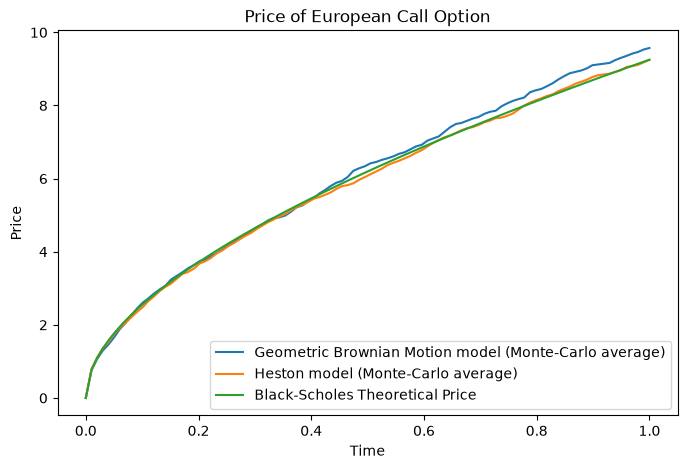

In [19]:
# Compute Monte Carlo price paths for GBM and Heston 
gbm_call_price_process = []
heston_call_price_process = []
bsm_call_price_process = []

# Computation for GBM
for time in ts:
    p = pricer.option_price_mc(ts, paths_array_gbm, time, K, R)
    gbm_call_price_process.append(p)

# Computation for Heston
for time in t:
    p = pricer.option_price_mc(t, paths_array_heston, time, K, R)
    heston_call_price_process.append(p)

tt = np.linspace(0, T, STEPS + 1)
for time in tt:
    # note Black-Scholes doesn't work at T=0 since we divide by T
    if time == 0:
        bsm_call_price_process.append(0)
    else:
        p = pricer.option_price_bsm(S_0, K, time, R, SIGMA)
        bsm_call_price_process.append(p)

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(ts, gbm_call_price_process, label='Geometric Brownian Motion model (Monte-Carlo average)')
ax.plot(t, heston_call_price_process, label='Heston model (Monte-Carlo average)')
ax.plot(tt, bsm_call_price_process, label='Black-Scholes Theoretical Price')
ax.set_title("Price of European Call Option")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.show()

We observe that the Heston model is slightly more accurate, although both models are very close to the theoretical price with this number of samples. 

## 3. Classic Delta Hedging

We would like to compare Buehler's deep hedging to classic delta hedging. In this section we implement classic delta hedging. 

We simulate a market maker that has sold 100 European calls for a share; the market maker computes the delta of a call using Black-Scholes at short time intervals and buys however many of the underlying shares are needed to offset the delta. 

**Example.** If the initial call delta was +0.43, the market maker would purchase 43 shares. Suppose this rises to +0.5, then the market maker would purchase 7 more shares. 

Note: Since market makers typically have extremely large portfolios, the position can be modelled as continuous without having to round to a whole number of shares.

We recall that according to Black-Scholes, the delta of an asset is given by the formula 

$\frac{\partial V}{\partial S} =\frac{\log (S_0 /K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma \sqrt{T}}$

which the reader may recall was a term in the Black-Scholes pricing formula we saw earlier. 

We implement the corresponding delta hedging strategy as ``deltahedge.delta_hedge()``. We show how this looks for the first GBM and Heston asset trajectory. 

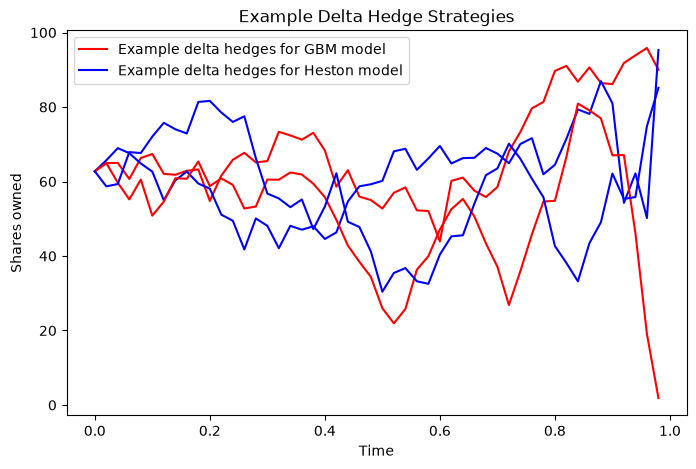

In [65]:
PATHS_TO_TEST = 2

test_gbm_paths = np.array(paths_array_gbm[0:PATHS_TO_TEST])
test_heston_paths = np.array(paths_array_heston[0:PATHS_TO_TEST])

t1, gbm_delta_hedge = deltahedge.delta_hedge_batch(test_gbm_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)
t2, heston_delta_hedge = deltahedge.delta_hedge_batch(test_heston_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)

fig, ax = plt.subplots(1, 1, figsize=(8,5))

for i in range(PATHS_TO_TEST):
    ax.plot(t1, gbm_delta_hedge[i], label='Example delta hedges for GBM model', color='r')
    ax.plot(t2, heston_delta_hedge[i], label='Example delta hedges for Heston model', color='b')

ax.set_title("Example Delta Hedge Strategies")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")

# short script for grouping labels together, see https://stackoverflow.com/a/36189073
handles, labels = plt.gca().get_legend_handles_labels()
labels, ids = np.unique(labels, return_index=True)
handles = [handles[i] for i in ids]
ax.legend(handles, labels, loc='best')

plt.show()


We compute the profit and loss (P&L) of this classic delta hedge. We shall model this using a self-financing portfolio. 

**Explanation of the model.** Let $N_t$ be the number of shares held at time $t$, then the total wealth of the hedger at hedging time $t$ is given by $W_t = N_t S_t + B_t$, where $B_t$ represents liquid cash in the bank account of the hedger and $N_t S_t$ is the value of the shares held by the hedger. We have computed $N_t$ as ``hedge_process`` in the previous cell, so we now need only look at the bank account. 

 Let's suppose the transaction rate is $c\in [0,1]$. At time $t=0$ the hedger receives a premium $C_0$ per option from selling the options (where $C_0$ is the initial price calculated using Black-Scholes using ``pricer.option_price_bsm()``), spends $N_0 S_0$ on the shares, and pays a transaction cost $c |N_0 | S_0$ on the trade:

$B_0 = C_0 n - N_0 S_0 - c |N_0 | S_0$

where $n$ is the number of calls sold. 

At each subsequent time step $t_i\rightarrow t_{i+1}$, two things happen, in this order: 

* First, the cash accrues interest, given by $B_i e^{r dt}$

* Secondly, the hedger rebalances by adjusting their stock holding from $N_{i}$ to $N_{i+1}$. Factoring in transaction costs, we must subtract $(N_{i+1} - N_i) S_{i+1} + c|N_{i+1} - N_i | S_{i+1}$ from the bank account. 

Putting both of these together, we arrive at the formula:

$B_{i+1} = B_i e^{r dt} - (N_{i+1} - N_i) S_{i+1} - c|N_{i+1} - N_i | S_{i+1}$.

Finally, at the maturity time $T$ (let's say this is the $I$ th rebalancing step), these two things don't happen, but instead:

* The hedger liquidates their stock position, earning $N_{I-1} S_T - c |N_{I-1}| S_T$

* The hedger owes the option payoff $n \max (S_T - K, 0)$ from selling the calls. 

In [51]:
C_0 = pricer.option_price_bsm(S_0, K, T, R, SIGMA)
COST_RATE = 0.001

gbm_pnl = deltahedge.delta_hedge_pnl(paths_array_gbm, S_0, C_0, K, R, SIGMA, CALLS_SOLD, COST_RATE, T, UPDATE_INTERVAL)
heston_pnl = deltahedge.delta_hedge_pnl(paths_array_heston, S_0, C_0, K, R, SIGMA, CALLS_SOLD, COST_RATE, T, UPDATE_INTERVAL)


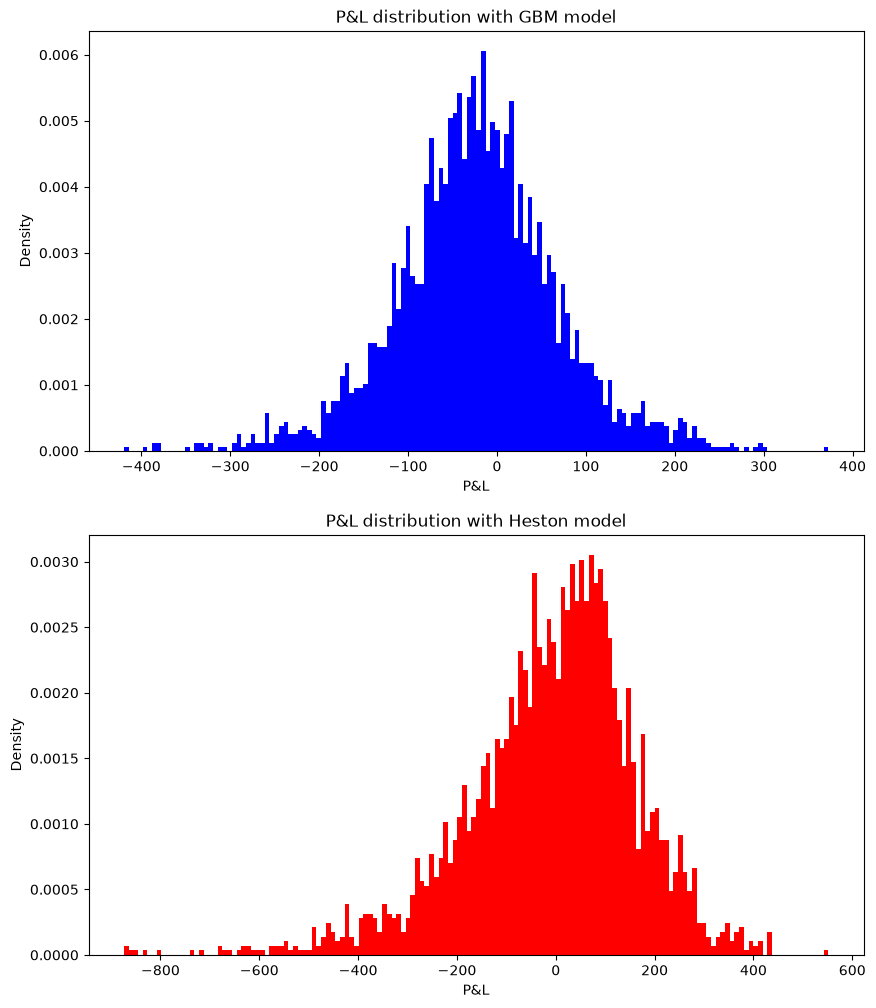

Statistics for P&L distribution with GBM model:

                 0
count  3000.000000
mean    -22.448567
std      92.325474
min    -419.626249
25%     -74.685646
50%     -22.673567
75%      31.329896
max     372.785380


Statistics for P&L distribution with Heston model:

                 0
count  3000.000000
mean    -10.015280
std     172.771038
min    -873.949336
25%    -102.129007
50%      11.882813
75%      98.769011
max     551.611619


In [52]:
# Plotting PNL distributions of both models 
fig, ax = plt.subplots(2, 1, figsize=(10,12))
ax[0].hist(gbm_pnl, bins=150, color='b', density=True)
ax[1].hist(heston_pnl, bins=150, color='r', density=True)
ax[0].set_title("P&L distribution with GBM model")
ax[1].set_title("P&L distribution with Heston model")

for i in range(2):
    ax[i].set_xlabel("P&L")
    ax[i].set_ylabel("Density")

plt.show()

# Print out some basic statistics using pandas summary 
gbm_pnl_df = pd.DataFrame(gbm_pnl)
heston_pnl_df = pd.DataFrame(heston_pnl)

print("Statistics for P&L distribution with GBM model:\n")
print(gbm_pnl_df.describe())
print("\n")
print("Statistics for P&L distribution with Heston model:\n")
print(heston_pnl_df.describe())

## Replacing delta hedging with deep hedging 

Now we instead train an LSTM to find a hedging strategy.

We train the LSTM to minimize the CVaR (at level 0.95) of the P&L distribution. The 0.95-CVaR of a portfolio can be interpreted as the expected return of the portfolio in the worst 95% of cases. 

We implement CVaR minimization using the following result of Rockafellar &
Uryasev: if $\Phi_\alpha$ is the $\alpha$-CVaR of a random variable, then
$\Phi_\alpha$ satisfies 

$\Phi_\alpha = \min_{x\in \mathbb{R}} \left[ x + \frac{1}{1-\alpha}
\int_{-\infty}^\infty (y-x)_+ p(y) dy \right]$.

or

$\Phi_\alpha = \min_{x\in \mathbb{R}} \left[ x + \frac{1}{1-\alpha}
\mathbb{E} [(y-x)_+ ]\right]$.

In particular, the minimizing value of $x$ is given by the $\alpha$ quantile of the P&L distribution.

(See for example:
https://statisticaloddsandends.wordpress.com/2024/04/15/cvar-and-a-lemma-from-rockafellar-uryasev/).

Therefore we can compute the CVaR using the following simple code: 

In [53]:
def cvar_np(pnl_distribution, alpha=0.95):
    losses = -np.asarray(pnl_distribution)
    q = np.quantile(losses, alpha)
    return q + np.mean(np.maximum(losses - q, 0.0)) / (1 - alpha)

print("The 0.95-CVaR of the delta hedging portfolio on GBM paths is ", cvar_np(gbm_pnl))

The 0.95-CVaR of the delta hedging portfolio on GBM paths is  231.51326607165757


Knowing the CVaR of standard delta hedging is also useful because it gives us a baseline to aim for. That is, ideally we would like the deep hedging model to outperform the CVaR of delta hedging. So we will aim to run the model for enough epochs so that CVaR is below this. 

aim: train LSTM to output path which minimizes alpha cvar 

LSTM input - matrix of asset price paths 
LSTM output - vector containing shares purchased path 

alpha VaR is just the alpha-quantile of the pnl distribution 
CVaR is the expected value of the loss conditional on the loss exceeding the alpha CVaR 


!Important! Our model has to take into account delta_{t-1} when predicting
delta_t, because we have a transaction cost of the form c|N_t - N_{t-1}|. 
because of this we build the model using LSTM cells 



In [54]:
# Train the deep hedging model 
COST_RATE = 0.001 # reset cost rate


EPOCHS = 1500
LR = 0.002 # learning rate 

INPUT_SIZE = 3 
HIDDEN_SIZE = 32 
LAYERS = 1
CONFIDENCE_LVL = 0.95

torch.manual_seed(42)
hedgingModel = deephedging.LSTMmodel(INPUT_SIZE, HIDDEN_SIZE, LAYERS, CONFIDENCE_LVL, COST_RATE, UPDATE_INTERVAL)
hedgingModel.trainModel(EPOCHS, LR, paths_per_maturity=30)


epoch   20  CVaR loss: 1090.2909  mean P&L: -16.7625
epoch   40  CVaR loss: 800.9286  mean P&L: 16.4102
epoch   60  CVaR loss: 759.3114  mean P&L: 2.9512
epoch   80  CVaR loss: 735.3690  mean P&L: -6.8463
epoch  100  CVaR loss: 581.7879  mean P&L: -2.1716
epoch  120  CVaR loss: 604.7851  mean P&L: 14.1969
epoch  140  CVaR loss: 532.9696  mean P&L: 0.0039
epoch  160  CVaR loss: 504.0305  mean P&L: -1.9753
epoch  180  CVaR loss: 530.2018  mean P&L: -1.6071
epoch  200  CVaR loss: 481.4713  mean P&L: -15.3840
epoch  220  CVaR loss: 457.8308  mean P&L: -7.9405
epoch  240  CVaR loss: 486.8361  mean P&L: -14.4483
epoch  260  CVaR loss: 461.6132  mean P&L: -4.8966
epoch  280  CVaR loss: 437.0755  mean P&L: -4.6590
epoch  300  CVaR loss: 464.3611  mean P&L: 3.3600
epoch  320  CVaR loss: 383.3673  mean P&L: -3.3173
epoch  340  CVaR loss: 452.9843  mean P&L: -4.0590
epoch  360  CVaR loss: 413.1748  mean P&L: -5.4491
epoch  380  CVaR loss: 437.0407  mean P&L: -1.4787
epoch  400  CVaR loss: 438.555

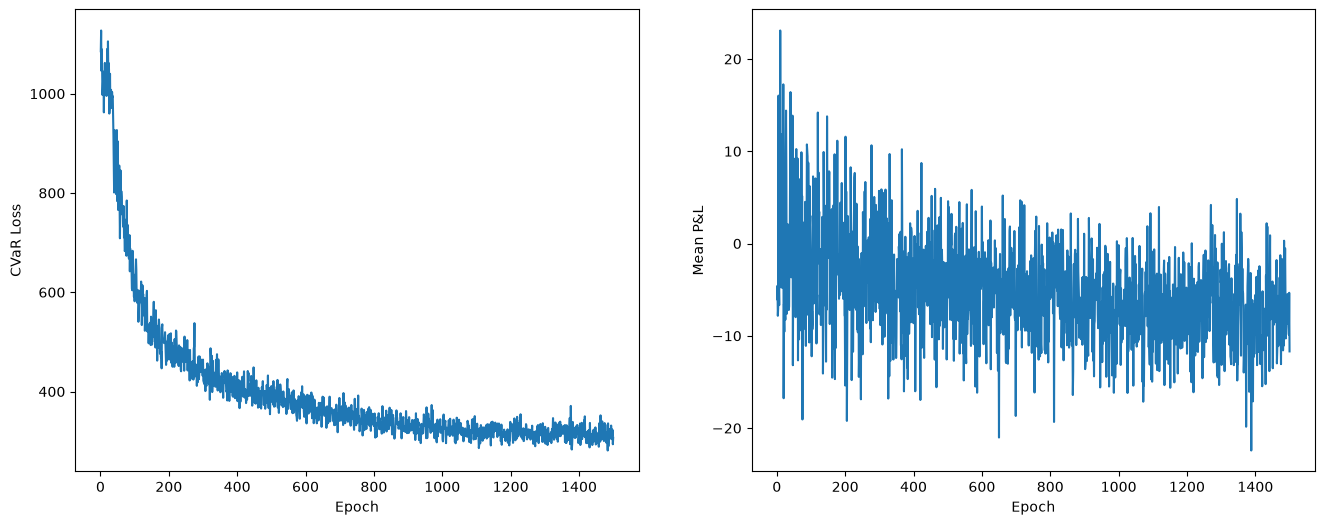

In [55]:
# plot CVaR loss graph over epochs 
fig, ax = plt.subplots(1, 2, figsize=(16,6)) 
ax[0].plot(hedgingModel.train_data['Epoch'], hedgingModel.train_data['CVaR loss'])
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("CVaR Loss") 

ax[1].plot(hedgingModel.train_data['Epoch'], hedgingModel.train_data['Mean P&L'])
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean P&L") 

plt.show()

# Model Evaluation

Let's see how the training PnL looks like on the training data: 

In [56]:
print(hedgingModel.train_data)

      Epoch    CVaR loss   Mean P&L
0         1  1085.472290  -6.032286
1         2  1127.299438  -4.575189
2         3  1045.918579  -7.827674
3         4  1089.484131  -6.986737
4         5  1048.816406  16.030575
...     ...          ...        ...
1495   1496   324.170349  -6.027755
1496   1497   310.914978  -8.992290
1497   1498   322.847260  -9.871780
1498   1499   293.817108  -5.336082
1499   1500   306.853119 -11.688241

[1500 rows x 3 columns]


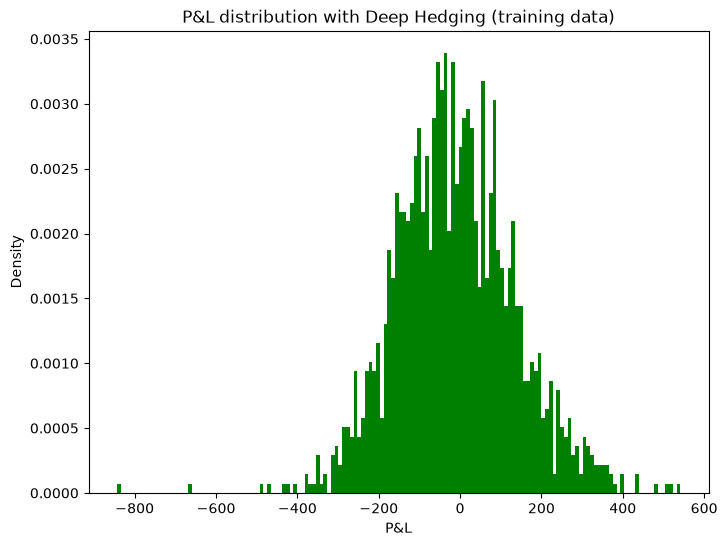

Statistics for P&L distribution with Deep Hedging (training data):

                 0
count  1500.000000
mean    -11.688242
std     146.606583
min    -843.867676
25%    -109.309763
50%     -18.436478
75%      81.831760
max     541.731567


In [60]:
# Plotting PNL distribution of deep hedging 
fig, ax = plt.subplots(1, 1, figsize=(8,6))
pnl_dist = hedgingModel.pnl_dist.detach().numpy()
ax.hist(pnl_dist, bins=150, label="PNL distribution with Deep Hedging", color='g', density=True)
ax.set_xlabel("P&L")
ax.set_ylabel("Density")
ax.set_title("P&L distribution with Deep Hedging (training data)") 

plt.show()

print("Statistics for P&L distribution with Deep Hedging (training data):\n")
print(pd.DataFrame(pnl_dist).describe())


Unlike standard delta hedging, here we actually have some probability of making a profit!
But it remains to see how the model performs on unseen test data.

# Test on unseen data 

We use the paths generated at the start of this notebook as a test dataset. For example, here's what the deep hedging paths for the first five Heston paths look like: 

In [73]:
prices = torch.from_numpy(paths_array_heston[:, ::hedgingModel.steps_per_hedge]).float()   # (N, 51)

print(prices.shape[1])

print(max_hedge_intervals)

50
50


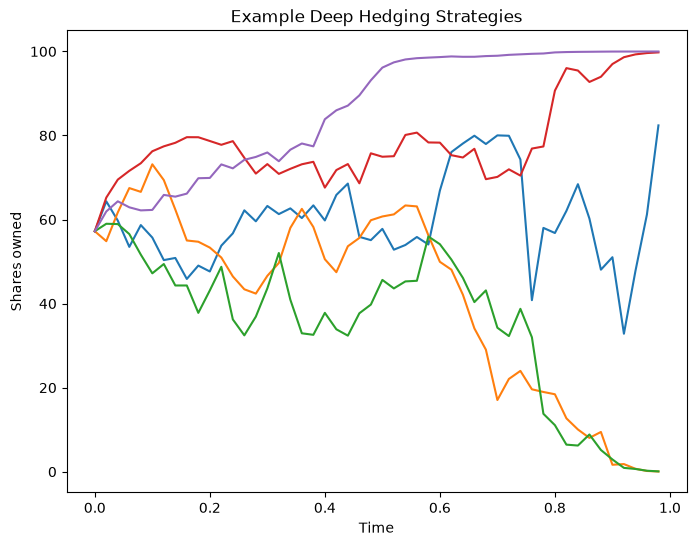

In [74]:
# use model to make predictions 
max_hedge_intervals = int(round(T / hedgingModel.dt))      # 50

def deep_hedge_on(paths_array):
    prices = torch.from_numpy(paths_array[:, ::hedgingModel.steps_per_hedge]).float()   
    #assert prices.shape[1] == max_hedge_intervals + 1
    steps_to_maturity = torch.full((prices.shape[0],), max_hedge_intervals, dtype=torch.long)
    with torch.no_grad():
        hedge, mask = hedgingModel.simulate_process(prices, CALLS_SOLD, steps_to_maturity)
    return hedge[:, :max_hedge_intervals].numpy()           

y_pred_heston = deep_hedge_on(paths_array_heston)
ts = np.arange(max_hedge_intervals) * hedgingModel.dt       # same 50 hedge times as np.arange(0, T, dt)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
for i in range(5):
    ax.plot(ts, y_pred_heston[i], label='Deep Hedge')

ax.set_title("Example Deep Hedging Strategies")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")
plt.show()


In [75]:
gbm_paths = np.array(paths_array_gbm)
heston_paths = np.array(paths_array_heston)

t1, gbm_delta_hedge = deltahedge.delta_hedge_batch(gbm_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)
t2, heston_delta_hedge = deltahedge.delta_hedge_batch(heston_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)

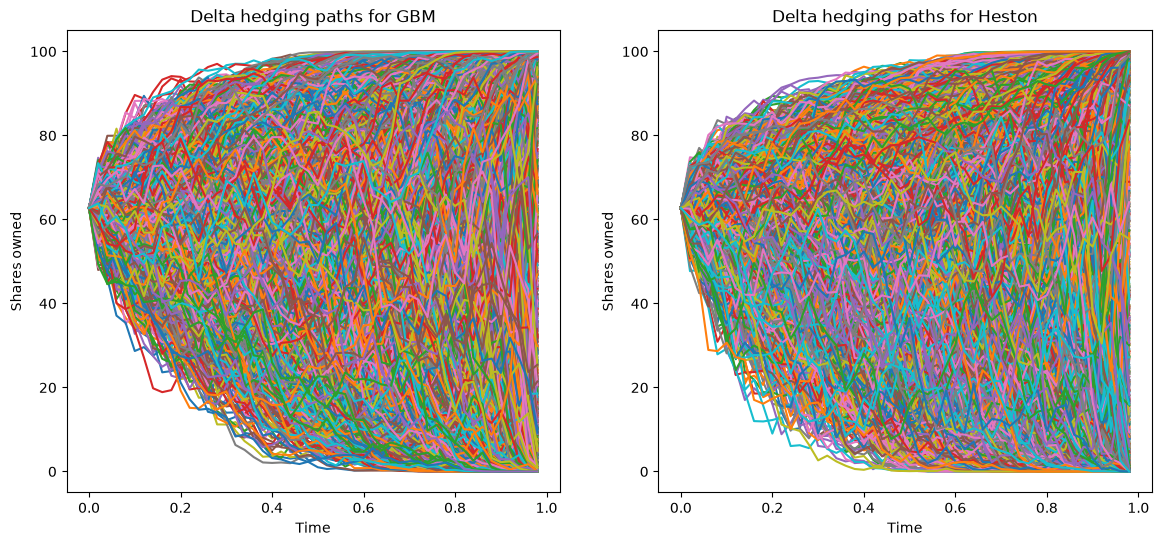

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

for i in range(3000):
    ax[0].plot(t1, gbm_delta_hedge[i])
    ax[1].plot(t2, heston_delta_hedge[i])

ax[0].set_title("Delta hedging paths for GBM") 
ax[1].set_title("Delta hedging paths for Heston")

for i in range(2):
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel("Shares owned")

plt.show()

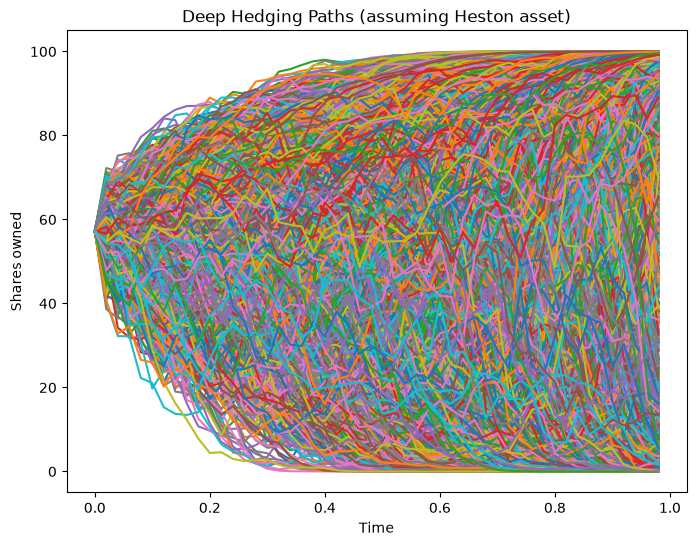

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
for i in range(3000):
    ax.plot(ts, y_pred_heston[i], label='Deep Hedge')

ax.set_title("Deep Hedging Paths (assuming Heston asset)")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")
plt.show()


Outputting all paths on a graph does not show a major difference; all three have similar overall shapes. 

Next we compute the empirical PnL on the test data. 

In [66]:
paths_array_gbm_torch = torch.from_numpy(paths_array_gbm).float()

y_pred_gbm = hedgingModel.simulate_process(paths_array_gbm_torch, CALLS_SOLD, T)


dh_empirical_pnl_gbm = compute_pnl_cash_account_torch(paths_array_gbm_torch, y_pred_gbm, K, C_0, 
                                                      CALLS_SOLD, COST_RATE, hedgingModel.dt, R).detach().numpy()
dh_empirical_pnl_heston = compute_pnl_cash_account_torch(paths_array_heston_torch, y_pred_heston, K, 
                                                         C_0, CALLS_SOLD, COST_RATE, hedgingModel.dt, R).detach().numpy()


fig, ax = plt.subplots(1, 2, figsize=(16,6))

ax[0].hist(dh_empirical_pnl_gbm, bins=150, color='r', density=True)
ax[0].set_xlabel("P&L")
ax[0].set_ylabel("Density")
ax[0].set_title("P&L distribution with Deep Hedging on (unseen) GBM Paths") 

ax[1].hist(dh_empirical_pnl_heston, bins=150, color='b', density=True)
ax[1].set_xlabel("P&L")
ax[1].set_ylabel("Density")
ax[1].set_title("P&L distribution with Deep Hedging on (unseen) Heston Paths") 

plt.show()

print("Statistics for P&L distribution with Deep Hedging on GBM Paths:\n")
print(pd.DataFrame(dh_empirical_pnl_gbm).describe())
print("\n")
print("Statistics for P&L distribution with Deep Hedging on Heston Paths:\n")
print(pd.DataFrame(dh_empirical_pnl_heston).describe())




AttributeError: 'float' object has no attribute 'clamp'

It is interesting to see that deep hedging performs reasonably well on GBM, despite the fact that the model was trained on Heston paths. 

# Comparison to Black-Scholes delta hedge under 0 trading costs 

We know that under zero training costs, classic Black-Scholes delta hedging is the theoretical optimal hedging method. Ideally if deep hedging has learned something like the 'correct' hedge given different training costs, we would expect it to recover paths close to Black-Scholes delta hedging when the cost is input as zero. 

More concretely: Recall that we implemented the function for the Black-Scholes delta hedge as `bsm_delta(S_0, K, r, sigma, T - t)`. This computes the theoretical delta of a European call under Black-Scholes-Merton given initial price $S_0$, strike price $K$, risk-free rate $r$, volatility $\sigma$, at time $T-t$ (where $T$ is the maturity time). Likewise, the delta hedging model contains a step function `step(S_t, T - t, delta_t, hidden_layers)` which predicts $\delta_{t+1}$ given $S_t$, $\delta_t$, and hidden layers from earlier steps in the model. Now we can initialize the hidden layer to an initial state using `init_hidden_layer(n)` to make this function depend only on $S_t$, $\delta_t$. We would like to verify that 

$bsm_delta(S_0, K, r, sigma, T - t) \approx 

In [48]:
COST_RATE = 0.0 # zero costs

EPOCHS = 1500
LR = 0.002 # learning rate 

INPUT_SIZE = 3 
HIDDEN_SIZE = 32 
LAYERS = 1
CONFIDENCE_LVL = 0.95


gbm_generator = lambda rng, n: gbm_paths_vec(rng, n, S_0, R, SIGMA, T, STEPS)

torch.manual_seed(42)
hedgingModel_zerocostgbm = deephedging.LSTMmodel(INPUT_SIZE, HIDDEN_SIZE, LAYERS, CONFIDENCE_LVL, COST_RATE, UPDATE_INTERVAL)
hedgingModel_zerocostgbm.trainModel(EPOCHS, LR, paths_per_maturity=30, path_generator=gbm_generator)

epoch   20  CVaR loss: 1060.4592  mean P&L: 7.7605
epoch   40  CVaR loss: 1005.6729  mean P&L: 1.1462
epoch   60  CVaR loss: 766.9927  mean P&L: 9.8258
epoch   80  CVaR loss: 757.3080  mean P&L: 7.7700
epoch  100  CVaR loss: 681.7407  mean P&L: -0.3015
epoch  120  CVaR loss: 612.6041  mean P&L: 8.1756
epoch  140  CVaR loss: 502.2001  mean P&L: -2.5352
epoch  160  CVaR loss: 465.5804  mean P&L: -3.9986
epoch  180  CVaR loss: 420.0982  mean P&L: 13.5377
epoch  200  CVaR loss: 428.8269  mean P&L: -6.9413
epoch  220  CVaR loss: 415.8885  mean P&L: -4.3304
epoch  240  CVaR loss: 385.1249  mean P&L: -0.8485
epoch  260  CVaR loss: 398.9124  mean P&L: -0.2072
epoch  280  CVaR loss: 363.3085  mean P&L: 5.0351
epoch  300  CVaR loss: 366.1039  mean P&L: -3.2820
epoch  320  CVaR loss: 367.1883  mean P&L: 3.7399
epoch  340  CVaR loss: 322.1003  mean P&L: 4.5021
epoch  360  CVaR loss: 322.8644  mean P&L: -3.2221
epoch  380  CVaR loss: 291.8872  mean P&L: 3.8355
epoch  400  CVaR loss: 300.5968  mean 

NameError: name 'hedgingModel_zerocostgbm' is not defined

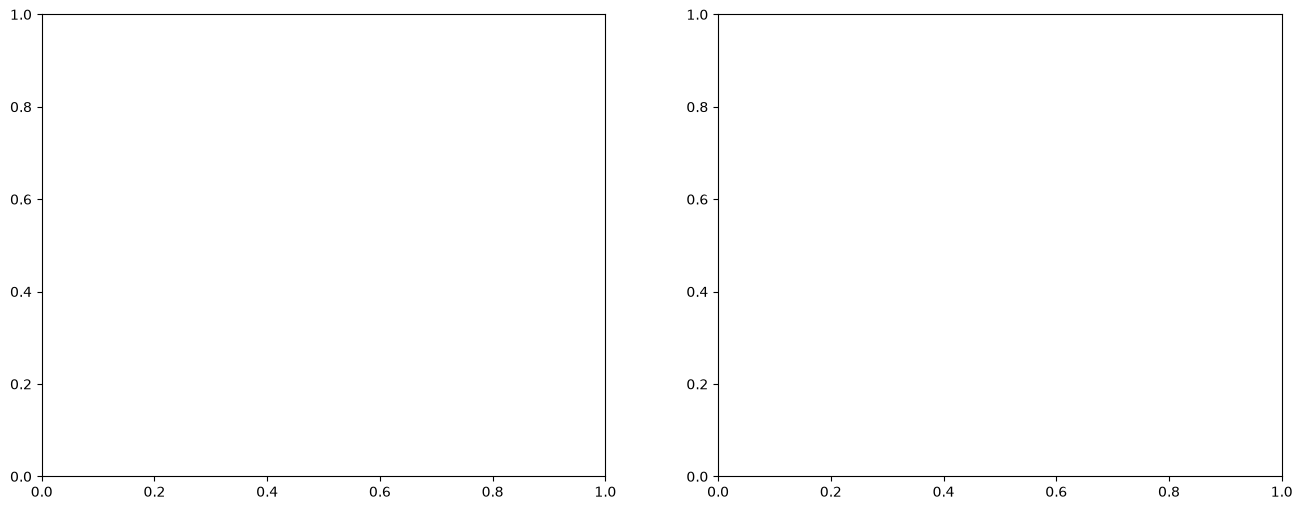

In [58]:
# plot CVaR loss graph over epochs 
fig, ax = plt.subplots(1, 2, figsize=(16,6)) 
ax[0].plot(hedgingModel_zerocostgbm.train_data['Epoch'], hedgingModel_zerocostgbm.train_data['CVaR loss'])
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("CVaR Loss") 

ax[1].plot(hedgingModel_zerocostgbm.train_data['Epoch'], hedgingModel_zerocostgbm.train_data['Mean P&L'])
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean P&L") 

plt.show()

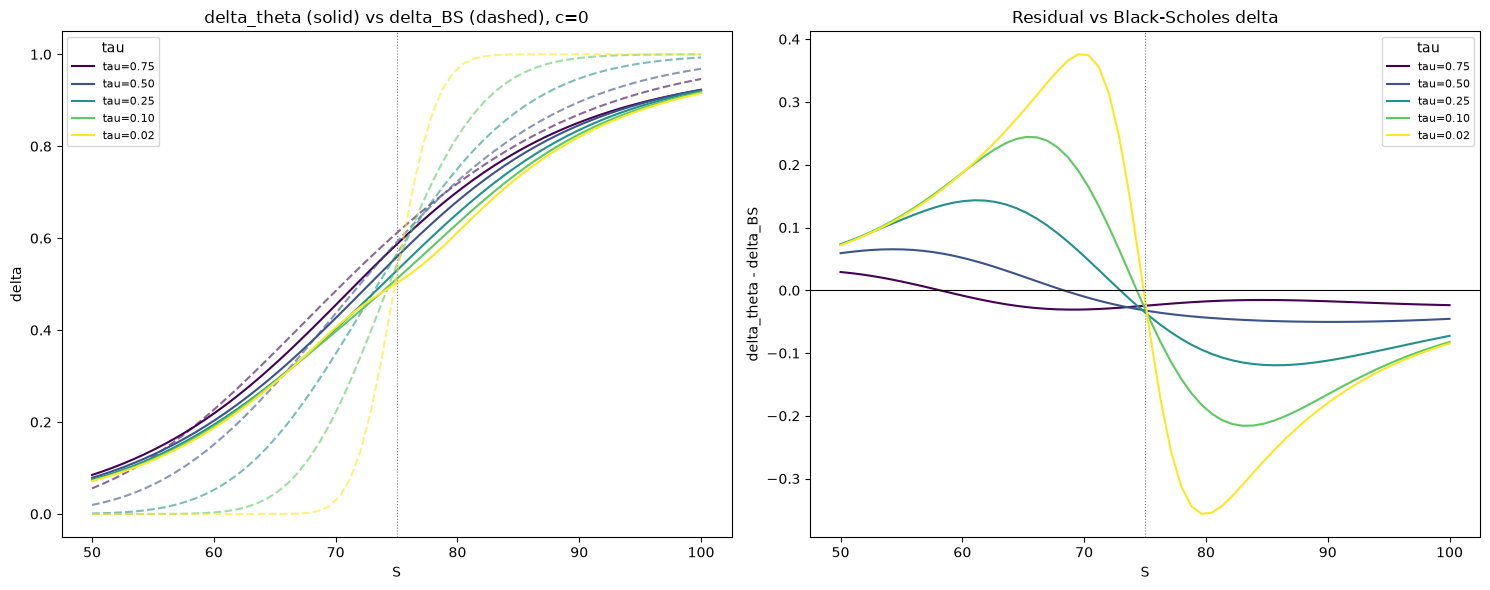

Max |residual| over grid: 0.3759
Mean |residual| over grid: 0.1036


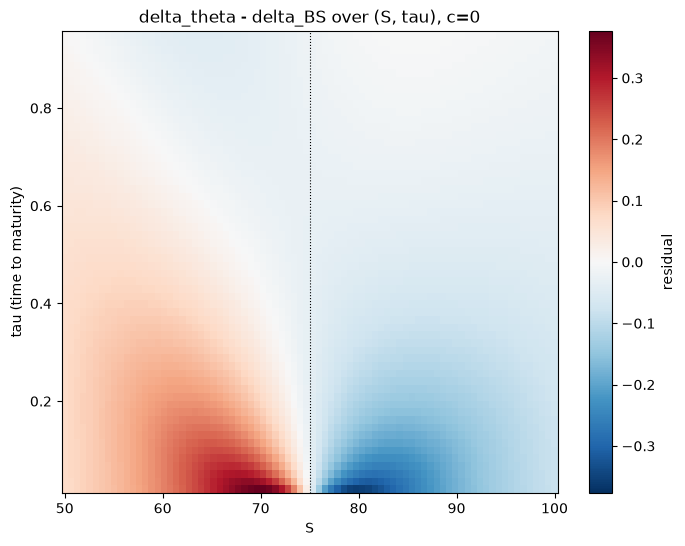

In [55]:
# ============================================================
# Verification Test 1: delta_theta(S, tau) vs delta_BS(S, tau) at c = 0
# ============================================================
#
# Extraction: we deliberately do NOT reuse simulate_process(), because that
# evaluates delta_theta along simulated *paths*, where S, tau, and delta_{t-1}
# all move together and confound the comparison. Instead we treat the network
# as the pure function f_theta(S, tau, delta_prev) that the architecture notes
# describe: fresh hidden state per query, single step() call over a full grid.
#
# delta_prev is set to delta_BS(S, tau) at each grid point (not a global
# constant), matching the "self-consistent" slice: if the network has
# converged, delta_prev should barely matter at c=0 anyway, so this choice
# only matters as a diagnostic for Test 2 later.

def extract_delta_theta_grid(model, S_grid, tau_grid, delta_prev_grid=None, K=None, r=None, sigma=None):
    """
    Evaluate the trained policy network as a pure function of (S, tau, delta_prev)
    over a grid, using a fresh hidden state for every query point (no path history).

    S_grid, tau_grid: 1D numpy arrays (need not be the same length)
    delta_prev_grid: optional 2D array matching the (S, tau) mesh; if None,
                      defaults to delta_BS(S, tau) at every grid point.

    Returns: (S_mesh, tau_mesh, delta_theta_mesh) all shape (len(tau_grid), len(S_grid))
    """
    S_mesh, tau_mesh = np.meshgrid(S_grid, tau_grid)  # shape (n_tau, n_S)
    n_tau, n_S = S_mesh.shape
    n = n_tau * n_S

    S_flat = torch.tensor(S_mesh.flatten(), dtype=torch.float32)
    tau_flat = torch.tensor(tau_mesh.flatten(), dtype=torch.float32)

    if delta_prev_grid is None:
        # self-consistent default: delta_prev = delta_BS(S, tau) pointwise
        delta_prev_mesh = bsm_delta(S_mesh, K, r, sigma, tau_mesh)
    else:
        delta_prev_mesh = delta_prev_grid
    delta_prev_flat = torch.tensor(delta_prev_mesh.flatten(), dtype=torch.float32)

    # fresh hidden state sized to the whole grid, evaluated in one batched call
    hidden = model.init_hidden_layer(n)
    with torch.no_grad():
        delta_out, _ = model.step(S_flat, tau_flat, delta_prev_flat, hidden)

    delta_theta_mesh = delta_out.numpy().reshape(n_tau, n_S)
    return S_mesh, tau_mesh, delta_theta_mesh


# ---- grid ----
S_grid = np.linspace(50, 100, 60)          # around K=75, wide enough to see both tails
tau_grid = np.array([0.75, 0.5, 0.25, 0.1, 0.02])  # skip tau=0 exactly (bsm_delta needs tau>0)

S_mesh, tau_mesh, delta_theta_mesh = extract_delta_theta_grid(
    hedgingModel_zerocostgbm, S_grid, tau_grid, K=K, r=R, sigma=SIGMA
)
delta_bs_mesh = bsm_delta(S_mesh, K, R, SIGMA, tau_mesh)
residual_mesh = delta_theta_mesh - delta_bs_mesh

# ---- Panel 1: overlay curves, one per tau ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cmap = plt.cm.viridis(np.linspace(0, 1, len(tau_grid)))
for i, tau in enumerate(tau_grid):
    axes[0].plot(S_grid, delta_bs_mesh[i], '--', color=cmap[i], alpha=0.6)
    axes[0].plot(S_grid, delta_theta_mesh[i], '-', color=cmap[i],
                 label=f'tau={tau:.2f}')

axes[0].axvline(K, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_xlabel("S")
axes[0].set_ylabel("delta")
axes[0].set_title("delta_theta (solid) vs delta_BS (dashed), c=0")
axes[0].legend(title="tau", fontsize=8)

# ---- Panel 2: residual ----
for i, tau in enumerate(tau_grid):
    axes[1].plot(S_grid, residual_mesh[i], color=cmap[i], label=f'tau={tau:.2f}')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(K, color='gray', linewidth=0.8, linestyle=':')
axes[1].set_xlabel("S")
axes[1].set_ylabel("delta_theta - delta_BS")
axes[1].set_title("Residual vs Black-Scholes delta")
axes[1].legend(title="tau", fontsize=8)

plt.tight_layout()
plt.show()

print("Max |residual| over grid: %.4f" % np.max(np.abs(residual_mesh)))
print("Mean |residual| over grid: %.4f" % np.mean(np.abs(residual_mesh)))

# ---- Panel 3: full (S, tau) heatmap of the residual ----
S_grid_fine = np.linspace(50, 100, 80)
tau_grid_fine = np.linspace(0.02, 0.95, 60)
S_mesh_f, tau_mesh_f, delta_theta_mesh_f = extract_delta_theta_grid(
    hedgingModel_zerocostgbm, S_grid_fine, tau_grid_fine, K=K, r=R, sigma=SIGMA
)
delta_bs_mesh_f = bsm_delta(S_mesh_f, K, R, SIGMA, tau_mesh_f)
residual_mesh_f = delta_theta_mesh_f - delta_bs_mesh_f

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.pcolormesh(S_grid_fine, tau_grid_fine, residual_mesh_f,
                    shading='auto', cmap='RdBu_r',
                    vmin=-np.max(np.abs(residual_mesh_f)),
                    vmax=np.max(np.abs(residual_mesh_f)))
ax.axvline(K, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel("S")
ax.set_ylabel("tau (time to maturity)")
ax.set_title("delta_theta - delta_BS over (S, tau), c=0")
fig.colorbar(im, ax=ax, label="residual")
plt.show()

In [53]:
def cvar_np(pnl, alpha=0.95):
    losses = -np.asarray(pnl)
    q = np.quantile(losses, alpha)
    return q + np.mean(np.maximum(losses - q, 0.0)) / (1 - alpha)

def bs_delta_hedge_process(prices_hedge, intervals_to_maturity, dt, no_of_calls):
    prices = prices_hedge.detach().numpy() if torch.is_tensor(prices_hedge) else np.asarray(prices_hedge)
    n = intervals_to_maturity.detach().numpy() if torch.is_tensor(intervals_to_maturity) else np.asarray(intervals_to_maturity)
    col = np.arange(prices.shape[1])[None, :]
    col_frozen = np.minimum(col, n[:, None] - 1)            # position frozen after the last decision date
    S_at = np.take_along_axis(prices, col_frozen, axis=1)
    tau = (n[:, None] - col_frozen) * dt                    # always >= dt, so no division by zero
    return torch.from_numpy(bsm_delta(S_at, K, R, SIGMA, tau) * no_of_calls).float()

network   mean    0.45  CVaR95   204.5  T=1-only CVaR95   202.5
BS delta  mean    0.28  CVaR95   212.2  T=1-only CVaR95   241.2
mean |residual| all steps: 0.0390   excluding step 0: 0.0404   step 0 only: 0.0043


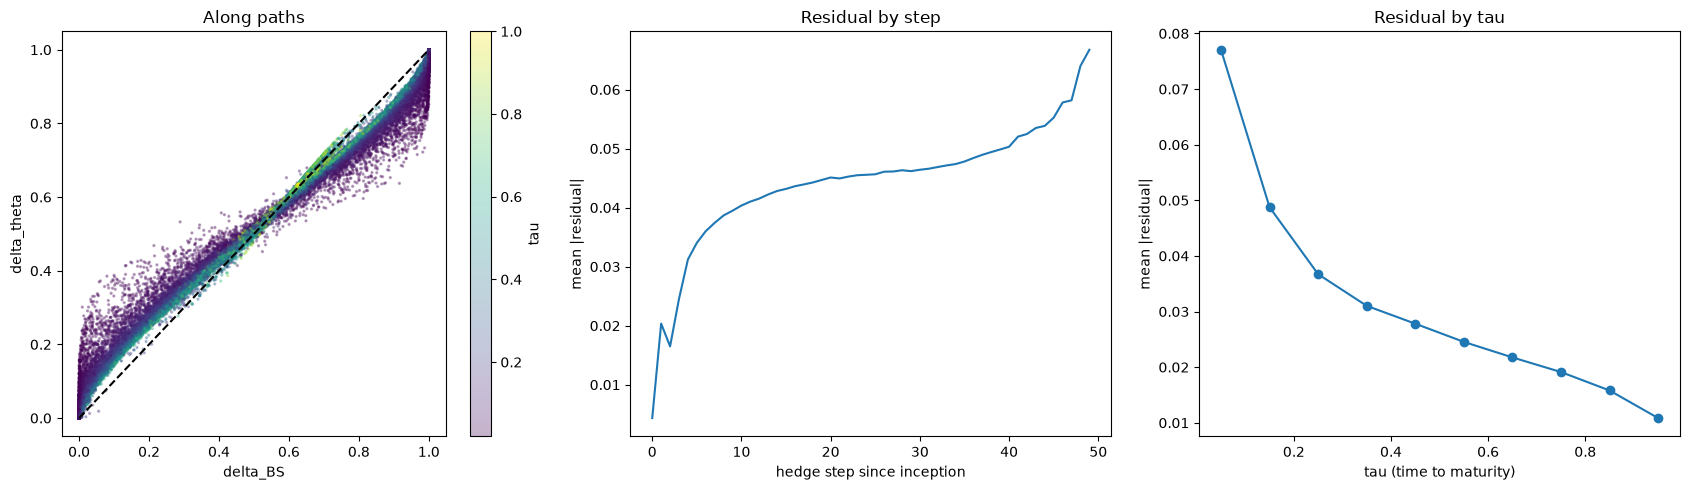

In [54]:
def path_policy_diagnostic(model, prices, iv, max_points=40000, seed=0):
    prices_t = torch.from_numpy(prices).float()
    with torch.no_grad():
        net_delta, active = model.simulate_process(prices_t, 1, torch.from_numpy(iv))  # no_of_calls=1 -> raw delta
    net_delta, active = net_delta.numpy(), active.numpy()

    n_points = prices.shape[1]
    step_index = np.broadcast_to(np.arange(n_points)[None, :], active.shape)
    tau = (iv[:, None] - np.arange(n_points)[None, :]) * model.dt     # > 0 wherever active

    S_a, tau_a, step_a = prices[active], tau[active], step_index[active]
    d_nn = net_delta[active]
    d_bs = bsm_delta(S_a, K, R, SIGMA, tau_a)
    resid = d_nn - d_bs

    print(f"mean |residual| all steps: {np.abs(resid).mean():.4f}   "
          f"excluding step 0: {np.abs(resid[step_a > 0]).mean():.4f}   "
          f"step 0 only: {np.abs(resid[step_a == 0]).mean():.4f}")

    rng = np.random.default_rng(seed)
    pick = rng.choice(len(d_bs), size=min(max_points, len(d_bs)), replace=False)
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))

    sc = ax[0].scatter(d_bs[pick], d_nn[pick], c=tau_a[pick], s=2, alpha=0.3)
    ax[0].plot([0, 1], [0, 1], 'k--'); fig.colorbar(sc, ax=ax[0], label="tau")
    ax[0].set_xlabel("delta_BS"); ax[0].set_ylabel("delta_theta"); ax[0].set_title("Along paths")

    steps = np.arange(n_points)
    ax[1].plot(steps, [np.abs(resid[step_a == s]).mean() if (step_a == s).any() else np.nan for s in steps])
    ax[1].set_xlabel("hedge step since inception"); ax[1].set_ylabel("mean |residual|"); ax[1].set_title("Residual by step")

    bins = np.linspace(0, T, 11); which = np.digitize(tau_a, bins)
    ax[2].plot(0.5 * (bins[:-1] + bins[1:]), [np.abs(resid[which == b]).mean() for b in range(1, 11)], 'o-')
    ax[2].set_xlabel("tau (time to maturity)"); ax[2].set_ylabel("mean |residual|"); ax[2].set_title("Residual by tau")
    plt.tight_layout(); plt.show()

iv, prices, pnl = evaluate_on_common_batch(hedgingModel_zerocostgbm, gbm_generator)
for name, p in pnl.items():
    print(f"{name:9s} mean {p.mean():7.2f}  CVaR95 {cvar_np(p):7.1f}  T=1-only CVaR95 {cvar_np(p[iv == iv.max()]):7.1f}")
path_policy_diagnostic(hedgingModel_zerocostgbm, prices, iv)

In [56]:
def delta_prev_sensitivity(model, prices, iv, probe_steps=(5, 15, 30), eps=0.1):
    prices_t = torch.from_numpy(prices).float(); iv_t = torch.from_numpy(iv)
    hidden = model.init_hidden_layer(len(iv)); delta_prev = torch.zeros(len(iv))
    clone = lambda hc: ([h.clone() for h in hc[0]], [c.clone() for c in hc[1]])
    with torch.no_grad():
        for i in range(prices_t.shape[1]):
            active = i < iv_t
            tau = ((iv_t - i) * model.dt).clamp(min=1e-6)
            S_i = prices_t[:, i]
            if i in probe_steps:
                up, _ = model.step(S_i, tau, (delta_prev + eps).clamp(0, 1), clone(hidden))
                dn, _ = model.step(S_i, tau, (delta_prev - eps).clamp(0, 1), clone(hidden))
                sens = ((up - dn) / (2 * eps))[active]
                print(f"step {i}: mean |d delta_out / d delta_prev| = {sens.abs().mean():.4f}")
            new, hidden = model.step(S_i, tau, delta_prev, hidden)
            delta_prev = torch.where(active, new, delta_prev)

delta_prev_sensitivity(hedgingModel_zerocostgbm, prices, iv)

step 5: mean |d delta_out / d delta_prev| = 0.0847
step 15: mean |d delta_out / d delta_prev| = 0.0734
step 30: mean |d delta_out / d delta_prev| = 0.0586
